# Template matching detection

This notebook display how to use `cle.local_cross_correlation()` to detect structure in an image

In [27]:
import numpy as np
import pyclesperanto as cle
from skimage.io import imread
import matplotlib.pyplot as plt
import scipy.ndimage as ndi

cle.select_device()

(OpenCL) Apple M5 Max (OpenCL 1.2)
	Vendor:                      Apple
	Driver Version:              1.2 1.0
	Device Type:                 GPU
	Compute Units:               40
	Global Memory Size:          53084 MB
	Local Memory Size:           0 MB
	Maximum Buffer Size:         9953 MB
	Max Clock Frequency:         1000 MHz
	Image Support:               Yes

## Blob detection

(np.float64(-0.5), np.float64(255.5), np.float64(253.5), np.float64(-0.5))

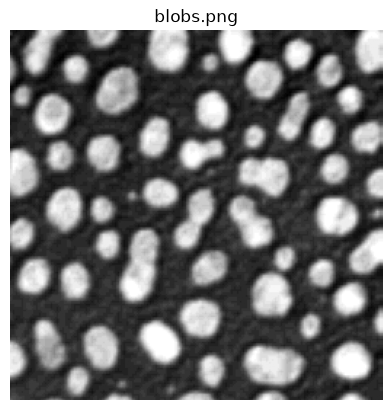

In [28]:
image = cle.push(imread('https://samples.fiji.sc/blobs.png').squeeze())
plt.imshow(image.get(), cmap='gray')
plt.title("blobs.png")
plt.axis("off")

Here, we will rely on an artificial template we made with a gaussian blur to simulate a blob.

min: 0.0001234098 max: 1.0


(np.float64(-0.5), np.float64(23.5), np.float64(23.5), np.float64(-0.5))

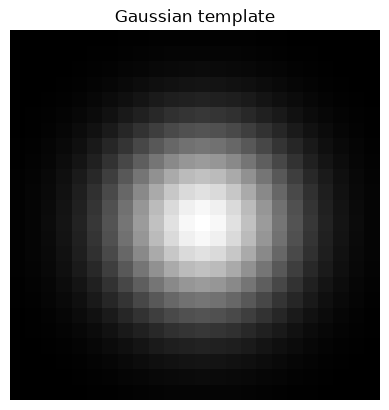

In [29]:
template_size = 24
sigma = 4

coords = np.arange(template_size) - template_size // 2
xx, yy = np.meshgrid(coords, coords)
gaussian_template = np.exp(-(xx**2 + yy**2) / (2 * sigma**2)).astype(np.float32)
template = cle.push(gaussian_template)

print("min:", template.min(), "max:", template.max())
plt.imshow(template.get(), cmap='gray')
plt.title("Gaussian template")
plt.axis("off")

`cle.local_cross_correlation()` slides the template over the image and produces a map whose
value is high wherever the local neighbourhood looks like the template. `cle.undefined_to_zero()`
cleans up border pixels where the correlation could not be computed.

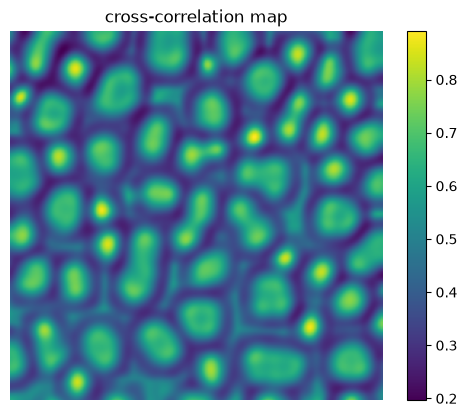

In [30]:
ccorr = cle.local_cross_correlation(image, template)
ccorr = cle.undefined_to_zero(ccorr)
plt.imshow(ccorr.get(), cmap='viridis')
plt.title("cross-correlation map")
plt.axis("off")
plt.colorbar()

We use`cle.detect_maxima()` to find **all** local maxima of the cross-correlation map within a given
neighborhood radius. We then keep only maxima above an intensity threshold to discard weak,
spurious correlation peaks; each remaining maximum corresponds to the centre of a detected
round structure.

detected 98 round structures


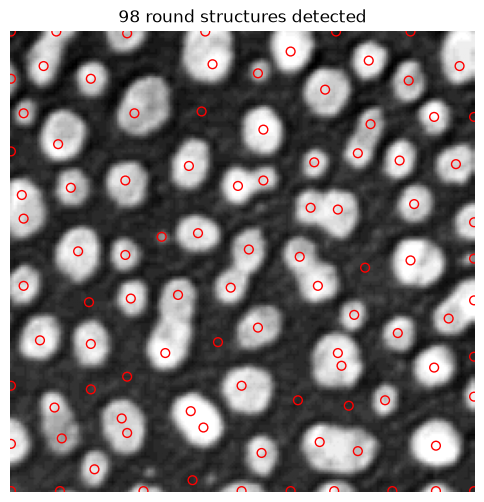

In [31]:
radius = 5
threshold_ratio = 0.5

maxima_mask = cle.detect_maxima(ccorr, radius_x=radius, radius_y=radius)
threshold_value = threshold_ratio * float(ccorr.max())
strong_maxima = cle.binary_and(maxima_mask, ccorr > threshold_value)

coordinates = np.argwhere(strong_maxima.get() > 0)
print(f"detected {len(coordinates)} round structures")

plt.figure(figsize=(6, 6))
plt.imshow(image.get(), cmap='gray')
plt.scatter(coordinates[:, 1], coordinates[:, 0], s=40, facecolors='none', edgecolors='r')
plt.title(f"{len(coordinates)} round structures detected")
plt.axis("off")
plt.show()

## Stack registration

We can also use it to align a stack of images based on a template which is present throughout the entire stack.

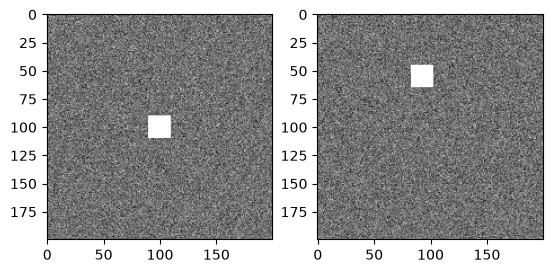

In [32]:
unaligned_stack = np.random.normal(size=(50, 200, 200))

# add a white box in a random location to each image in the stack
BOX_SIZE = 20
image_shape = unaligned_stack[0].shape

for i in range(len(unaligned_stack)):
    
    if i == 0:
        # place the box in the centre of the first image
        offset_x = image_shape[0] // 2 - BOX_SIZE // 2
        offset_y = image_shape[1] // 2 - BOX_SIZE // 2
    else:
        offset_x = int(np.random.random() * (image_shape[0]-BOX_SIZE))
        offset_y = int(np.random.random() * (image_shape[1]-BOX_SIZE))
        
    unaligned_stack[i, offset_x:offset_x+BOX_SIZE, offset_y:offset_y+BOX_SIZE] = 5

fig, axs = plt.subplots(1, 2)
axs[0].imshow(unaligned_stack[0], cmap='gray')
axs[1].imshow(unaligned_stack[1], cmap='gray')

Template matching translates images in the x and y directions to align each image based on a common subimage. In this example, the images can be aligned based on the white square in the first image.

First, we must define a template to search for within each image. We can crop the white square in the first image to be used as our template.

min: 5.0 max: 5.0


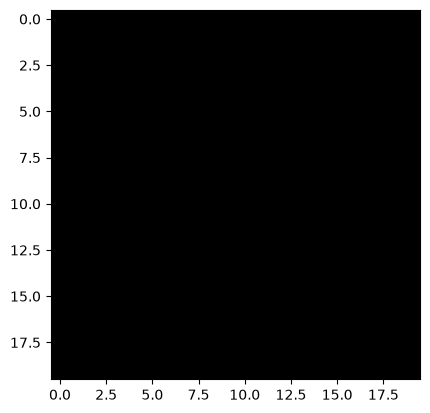

In [33]:
template = unaligned_stack[0, 90:110, 90:110]
print("min:",template.min(), "max:",template.max())
plt.imshow(template, cmap='gray')


Next, we can use cross correlation to search for the template within each image. The location of the maximum value in this array should give the location of the template in the image.

We can obtain the template location for the first image which we can use to calculate the offsets required to centre the remaining images.

base_location: (np.int64(100), np.int64(100))


array([[-0.45312268, -0.3883038 , -0.3337808 , ...,  0.00649797,
         0.04364702,  0.06177045],
       [-0.42726824, -0.366244  , -0.31372583, ...,  0.01663658,
         0.05345451,  0.0674291 ],
       [-0.35176772, -0.29906085, -0.25366685, ...,  0.00996126,
         0.03785743,  0.05768054],
       ...,
       [-0.03721733, -0.05052902, -0.04516454, ...,  0.24961616,
         0.25585955,  0.37619755],
       [-0.02694489, -0.04757456, -0.04084167, ...,  0.29363757,
         0.30352044,  0.44786254],
       [-0.03709373, -0.06329475, -0.05821898, ...,  0.29008466,
         0.3021203 ,  0.45727634]], shape=(200, 200), dtype=float32, mtype=buffer)
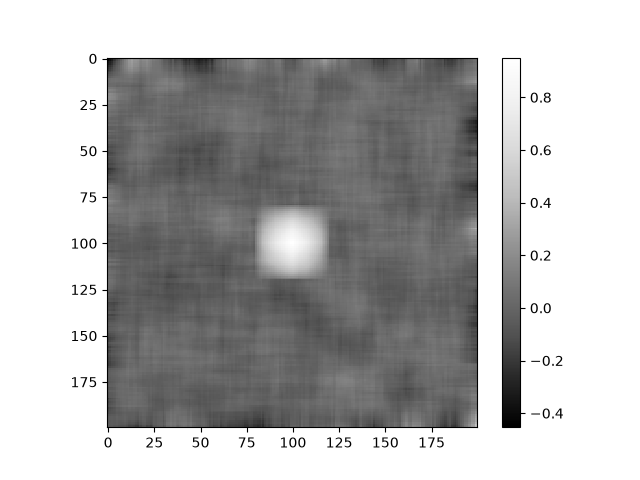
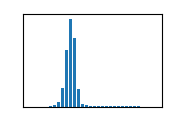

In [34]:
ccorr = cle.local_cross_correlation(unaligned_stack[0], template)
ccorr = cle.undefined_to_zero(ccorr)
base_location = ndi.maximum_position(ccorr)
print(f"base_location: {base_location}")
ccorr

Finally, we can calculate the location of the template within the remaining images and use a transformation to align them.

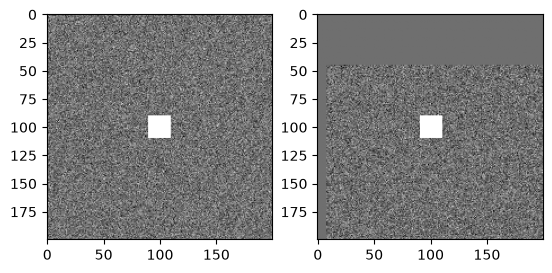

In [35]:
aligned_stack = np.zeros(unaligned_stack.shape)
for i in range(0, len(unaligned_stack)):
    # calculate the cross correlation for the given image and template
    ccorr = cle.local_cross_correlation(unaligned_stack[i], template)
    
    # obtain the location of the template within the image
    location = ndi.maximum_position(ccorr)

    # calculate the offsets using the location of the template in the first image
    offset_x = base_location[1] - location[1]
    offset_y = base_location[0] - location[0]
    
    # transform the images using the given offsets
    aligned_slice = cle.translate(unaligned_stack[i], translate_x=offset_x, translate_y=offset_y)
    aligned_stack[i, :, :] = aligned_slice.get()

# show the aligned images
fig, axs = plt.subplots(1, 2)
axs[0].imshow(aligned_stack[0], cmap='gray')
axs[1].imshow(aligned_stack[1], cmap='gray')